# Data analysis of changes in CO2 emissions per capita, between 2000 and 2018

### Get a world overview by creating a color coded scatterplot, looking into population size, GDP per capita, and emission changes.

### Create top list for the 10 best and 10 worst countries when it comes to changes in CO2 emissions per capita.

In [2]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Load data, rename columns, extract feature vectors

In [3]:
# Load data from csv file
data = pd.read_csv('CO2extra.csv', sep = ';')       


#rename some column names from Swedish to english
data.rename(columns = {'country': 'Country', 'BNP/capita': 'GDP/capita', 'Befolkningsmängd':'Population', 'Medellivslängd':'Life Expectancy'}, inplace = True)

#Display the first few rows of the dataset
data.head()


,Country,CO2 2000,CO2 2018,GDP/capita,Population,Region,Life Expectancy
0,Afghanistan,0.037,0.254,571,38000000,south_asia,64.1
1,Albania,0.966,1.590,5210,2880000,europe_central_asia,78.5
2,Algeria,2.820,3.690,4710,43100000,middle_east_north_africa,78.1
3,Angola,0.581,1.120,3100,31800000,sub_saharan_africa,65.0
4,Antigua and Barbuda,4.540,5.880,15700,97100,america,77.3


- Data in `CO2 2000` contains information of CO2-emission per person in Metric ton, for year 2000
- Data in `CO2 2018` contains information of CO2-emission per person in Metric ton, for year 2018
- Other features are self-explanatory.

In [4]:
# take a look at the data for Sweden
data[data['Country'] == 'Sweden']

,Country,CO2 2000,CO2 2018,GDP/capita,Population,Region,Life Expectancy
147,Sweden,6.16,4.12,58000,10000000,europe_central_asia,82.8


In [5]:
# Extract numpy-arrays from dataframe
country_arr = data['Country'].to_numpy()
CO2_2000_arr = data['CO2 2000'].to_numpy()  
CO2_2018_arr = data['CO2 2018'].to_numpy()
GDP_arr = data['GDP/capita'].to_numpy()
population_arr = data['Population'].to_numpy()


### Process data in order to make scales more suitable for a scatter plot

In [6]:
# Create a new array with the base-2 logarithm of each GDP per capita value.
# the value will be used on the X-axis for the scatter plot.
GDP_arr_log2= np.log2(GDP_arr) 


# scale the population array for better visualization in the scatter plot
# the size of the scatter points will be proportional to the square root of the population divided by 100.
population_arr_scaled = np.sqrt(population_arr)*(1/60)


# calculate the percentage change in CO2 emissions from 2000 to 2018 for each country
CO2_change = (CO2_2018_arr / CO2_2000_arr) - 1


# create a color coding, to be used in the scatter plot 
# color coding is based on the percentage change in CO2 emissions
colors = []
for x in CO2_change:
    
    if x <= -0.3 :          # If emissions went down with 30% or more - green color
        colors.append('g')
    
    elif x <= 0 :           # Elif emissions went down or stayed the same - blue color
        colors.append('b') 
    
    elif x <= 0.3 :         # Elif emissions increased with 30% or less - yellow color
        colors.append('y')
    
    elif x <= 1.0 :         # Elif emissions increased with max 100% - red color
        colors.append('r')
    
    else:                   # Elif emissions increased with more than 100% - black color
        colors.append('k')



color_dictionary = {'g': 'Decrease (30% or more)', 'b': 'Decrease (30% or less)', 'y': 'Increase (up to 30%)', 'r': 'Increase (30-100%)', 'k': 'Increase (over 100%)'}

#['Decrease (30% or more)', 'No change', 'Increase (up to 30%)', 'Increase (30-100%)', 'Increase (over 100%)']
legend_list = ['Decrease (30% or more)', 'Decrease (30% or less)', 'Increase (up to 30%)', 'Increase (30-100%)', 'Increase (over 100%)']

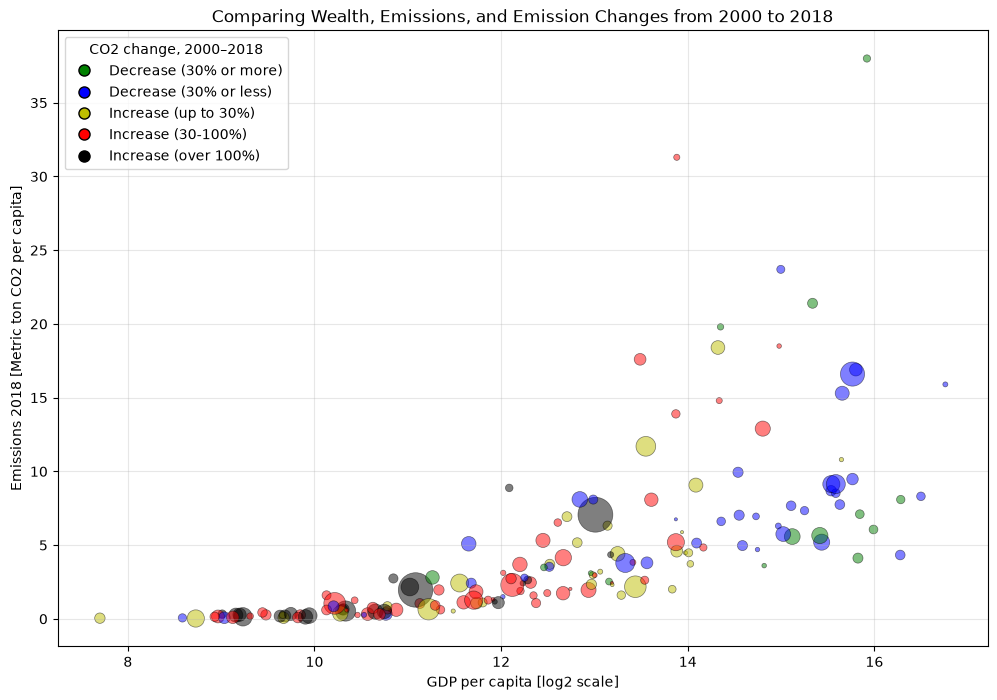

In [7]:
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(12, 8))

ax.scatter(GDP_arr_log2, CO2_2018_arr, c = colors, s = population_arr_scaled, alpha = 0.5, edgecolors = 'k', linewidth = 0.5)


ax.set_xlabel('GDP per capita [log2 scale]')
ax.set_ylabel('Emissions 2018 [Metric ton CO2 per capita]')
ax.set_title('Comparing Wealth, Emissions, and Emission Changes from 2000 to 2018')


legend_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=color,
           markeredgecolor='k', markersize=8, label=label)
    for color, label in zip(['g', 'b', 'y', 'r', 'k'], legend_list)]

ax.legend(handles=legend_handles, title='CO2 change, 2000–2018')


plt.grid(True, alpha=0.3)
plt.show()

### Look into which are the top 10 and bottom 10 countries - when it comes to decrease or increase of CO2 emissions per capita.

In [8]:
# Create a dictionary with countries and their corresponding CO2 change values.
CO2_dict = {'Country': country_arr,
        'CO2 change': CO2_change}


# create a DataFrame with countries and their corresponding CO2 change values.
CO2_df = pd.DataFrame(CO2_dict, columns=['Country','CO2 change'])


# sort the DataFrame by the 'CO2 change' column in ascending order.
CO2_df.sort_values(by=['CO2 change'], inplace=True)


# display the first few rows of the sorted DataFrame.
CO2_df.head()

,Country,CO2 change
96,Malta,-0.437695
162,Uzbekistan,-0.427699
159,United Kingdom,-0.413292
135,Singapore,-0.413223
113,North Macedonia,-0.411467


In [9]:
# create a list of CO2 change values in ascending order
CO2_low_to_high = CO2_df['CO2 change'].to_list()


# Create a list of countries corresponding to the CO2 change values in ascending order
countries_low_to_high = CO2_df['Country'].to_list()


# get the 10 countries with the largest percentage decrease in CO2 emissions from 2000 to 2018 and their corresponding percentage values.
best_values = CO2_low_to_high[:10]
best_values = [round(x*100) for x in best_values]


# create a list of the 10 countries with the largest percentage decrease in CO2 emissions from 2000 to 2018.
best_countries = countries_low_to_high[:10]


# create a list of the 10 countries with the largest percentage increase in CO2 emissions from 2000 to 2018 and their corresponding percentage values.
worst_values = CO2_low_to_high[-10:]
worst_values = [round(x*100) for x in worst_values] # *100 för att skapa %-värden


# create a list of the 10 countries with the largest percentage increase in CO2 emissions from 2000 to 2018.
worst_countries = countries_low_to_high[-10:]


print()
print ('Countries with the largest percentage decrease in CO2 emissions per capita, 2000 to 2018:')   
for i in range(10):
    print (best_countries[i]+':', best_values[i],'%')


print()
print ('Countries with the largest percentage increase in CO2 emissions per capita, 2000 to 2018:') 
for i in range(1,11):
    print (worst_countries[-i]+':', worst_values[-i], '%')




Countries with the largest percentage decrease in CO2 emissions per capita, 2000 to 2018:
Malta: -44 %
Uzbekistan: -43 %
United Kingdom: -41 %
Singapore: -41 %
North Macedonia: -41 %
Denmark: -41 %
United Arab Emirates: -40 %
Qatar: -35 %
Suriname: -33 %
Gabon: -33 %

Countries with the largest percentage increase in CO2 emissions per capita, 2000 to 2018:
Lao: 1422 %
Afghanistan: 586 %
Equatorial Guinea: 475 %
Cambodia: 293 %
Mozambique: 276 %
Vietnam: 230 %
Tanzania: 189 %
Mongolia: 184 %
Sudan: 172 %
Benin: 172 %
